# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities? 
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. (Optional) If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [93]:
# Part 1 : Data Wrangling and EDA ----------------------------------------------------------------------------------------------------------------

import pandas as pd

# Open The Data
df = pd.read_csv('data/cars_hw.csv')
print(df.head())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  


In [94]:
# Drop the useless index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Review data again
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

         Make  Make_Year   Color  Body_Type  Mileage_Run No_of_Owners  \
0  Volkswagen       2017  silver      sedan        44611          1st   
1     Hyundai       2016     red  crossover        20305          1st   
2       Honda       2019   white        suv        29540          2nd   
3     Renault       2017  bronze  hatchback        35680          1st   
4     Hyundai       2017  orange  hatchback        25126          1st   

   Seating_Capacity Fuel_Type Transmission Transmission_Type   Price  
0                 5    diesel      7-Speed         Automatic  657000  
1                 5    petrol      5-Speed            Manual  682000  
2                 5    petrol      5-Speed            Manual  793000  
3                 5    petrol      5-Speed            Manual  414000  
4                 5    petrol      5-Speed            Manual  515000  
(976, 11)
Make                 object
Make_Year             int64
Color                object
Body_Type            object
Mileage_Run  

In [ ]:
# Take a look at the summary statistics for the numeric columns
num_cols = ['Price', 'Make_Year', 'Mileage_Run', 'Seating_Capacity']
print(df[num_cols].describe())

              Price    Make_Year   Mileage_Run  Seating_Capacity
count  9.760000e+02   976.000000    976.000000        976.000000
mean   7.410195e+05  2016.963115  41571.195697          5.095287
std    3.673234e+05     2.818742  24390.995134          0.446224
min    1.880000e+05  2011.000000   1117.000000          4.000000
25%    4.757500e+05  2015.000000  22676.750000          5.000000
50%    6.665000e+05  2017.000000  37570.500000          5.000000
75%    8.830000e+05  2019.000000  57421.250000          5.000000
max    2.941000e+06  2022.000000  99495.000000          8.000000


In [96]:
import numpy as np

# Take the log of price and mileage as these values in the data are pretty sparse

df['log_price'] = np.log(df['Price'])
df['log_mileage'] = np.log(df['Mileage_Run'])

In [97]:
# Look at quantiles

q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Lower bound:", lower)
print("Upper bound:", upper)

# Outliers
print("Outliers:", ((df['Price'] < lower) | (df['Price'] > upper)).sum())

Lower bound: -135125.0
Upper bound: 1493875.0
Outliers: 54


In [98]:
# Exclude the outliers

df = df[df['Price'] <= upper].copy()

In [99]:
# Look at the milage outliers

q1_m = df['Mileage_Run'].quantile(0.25)
q3_m = df['Mileage_Run'].quantile(0.75)
iqr_m = q3_m - q1_m

lower_m = q1_m - 1.5 * iqr_m
upper_m = q3_m + 1.5 * iqr_m

# Check to make sure there are no more outliers
print("Mileage upper bound:", upper_m)
print("Mileage outliers:", ((df['Mileage_Run'] < lower_m) | (df['Mileage_Run'] > upper_m)).sum())
print(df.shape)

Mileage upper bound: 115025.5
Mileage outliers: 0
(922, 13)


In [100]:
import matplotlib.pyplot as plt

print(df['Price'].describe())

count    9.220000e+02
mean     6.768807e+05
std      2.563079e+05
min      1.880000e+05
25%      4.642500e+05
50%      6.470000e+05
75%      8.367500e+05
max      1.465000e+06
Name: Price, dtype: float64


In [101]:
# Summary stats for numeric columns updated

num_cols = ['Price', 'Make_Year', 'Mileage_Run', 'Seating_Capacity']
print(df[num_cols].describe())

              Price    Make_Year   Mileage_Run  Seating_Capacity
count  9.220000e+02   922.000000    922.000000        922.000000
mean   6.768807e+05  2016.796095  42203.131236          5.097614
std    2.563079e+05     2.803299  24709.561799          0.453260
min    1.880000e+05  2011.000000   1117.000000          4.000000
25%    4.642500e+05  2015.000000  22783.000000          5.000000
50%    6.470000e+05  2017.000000  38723.000000          5.000000
75%    8.367500e+05  2019.000000  59680.000000          5.000000
max    1.465000e+06  2022.000000  99495.000000          8.000000


In [102]:
# Summary stats for categorical columns updated

cat_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners',
            'Fuel_Type', 'Transmission', 'Transmission_Type']

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Make
Make
Hyundai          304
Maruti Suzuki    293
Honda             72
Renault           68
Ford              52
Toyota            50
Volkswagen        29
Mahindra          18
Tata              17
Chevrolet          6
Nissan             4
Skoda              4
Datsun             3
Jeep               1
Kia                1
Name: count, dtype: int64

Color
Color
white     181
red       173
grey      163
blue      127
silver    125
brown      70
black      26
orange     17
bronze     12
beige       9
yellow      6
purple      6
golden      3
maroon      2
green       2
Name: count, dtype: int64

Body_Type
Body_Type
hatchback    484
sedan        225
suv          154
muv           38
crossover     21
Name: count, dtype: int64

No_of_Owners
No_of_Owners
1st    764
2nd    154
3rd      4
Name: count, dtype: int64

Fuel_Type
Fuel_Type
petrol        762
diesel        158
petrol+cng      2
Name: count, dtype: int64

Transmission
Transmission
5-Speed    737
6-Speed    133
4-Speed     39
7-Speed 

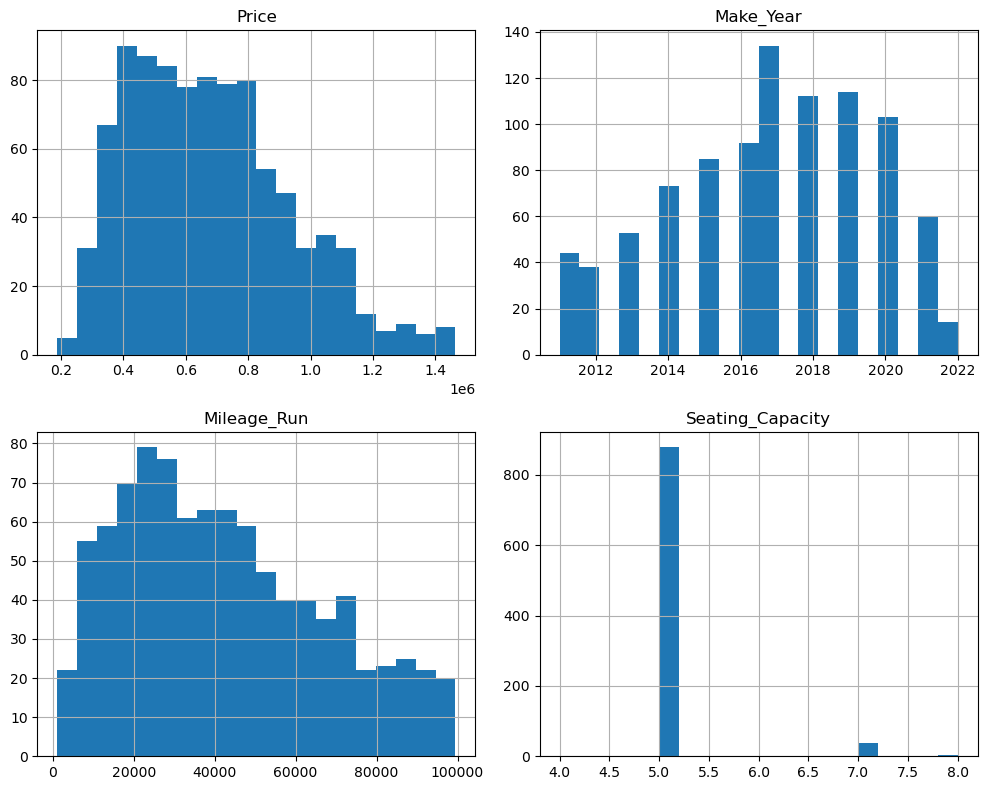

In [103]:
# Histograms for numeric columns

df[num_cols].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

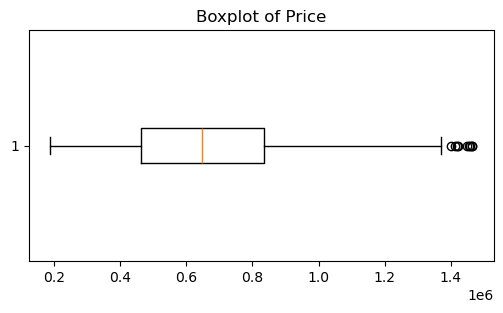

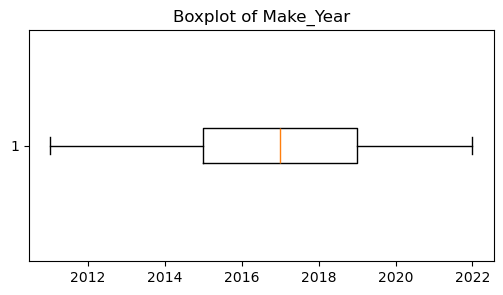

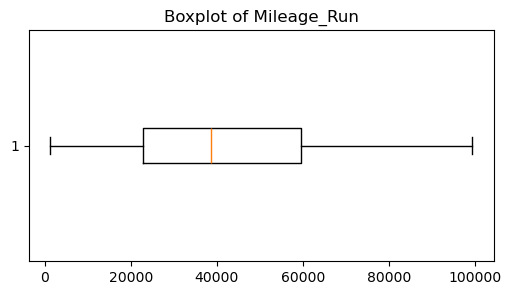

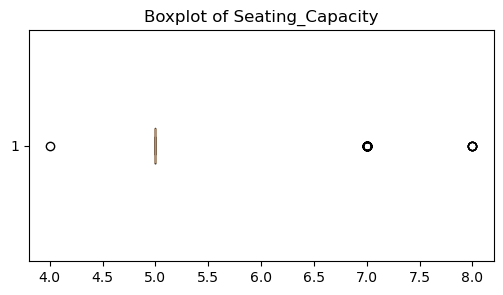

In [104]:
# Boxplots for numeric columns
for col in num_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()

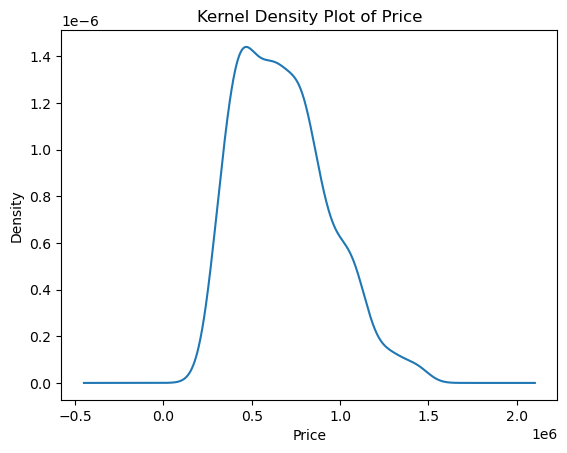

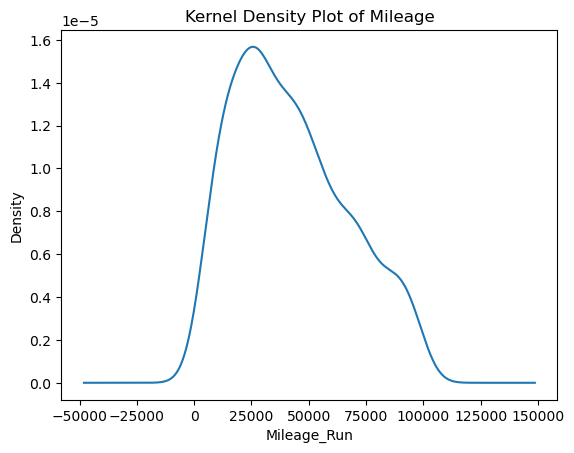

In [105]:
# Kernel Density Plots for numeric columns
df['Price'].plot(kind='kde')
plt.title('Kernel Density Plot of Price')
plt.xlabel('Price')
plt.show()

df['Mileage_Run'].plot(kind='kde')
plt.title('Kernel Density Plot of Mileage')
plt.xlabel('Mileage_Run')
plt.show()

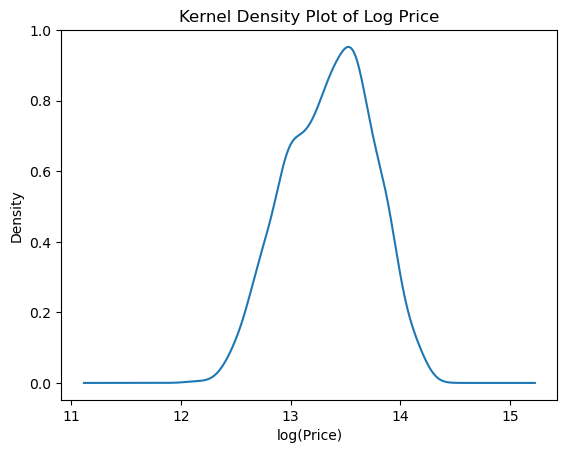

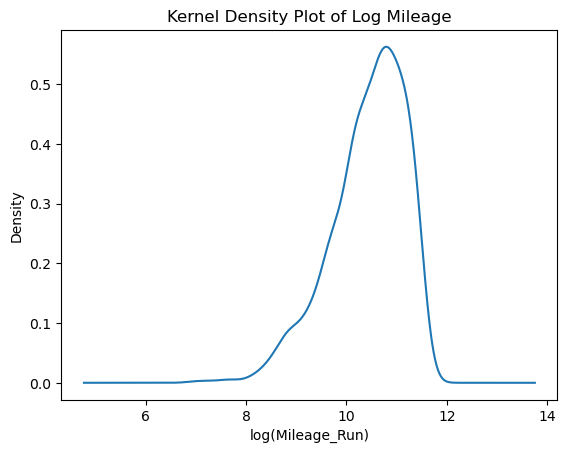

In [107]:
# Kernel Density Plots for log-transformed numeric columns
df['log_price'].plot(kind='kde')
plt.title('Kernel Density Plot of Log Price')
plt.xlabel('log(Price)')
plt.show()

df['log_mileage'].plot(kind='kde')
plt.title('Kernel Density Plot of Log Mileage')
plt.xlabel('log(Mileage_Run)')
plt.show()

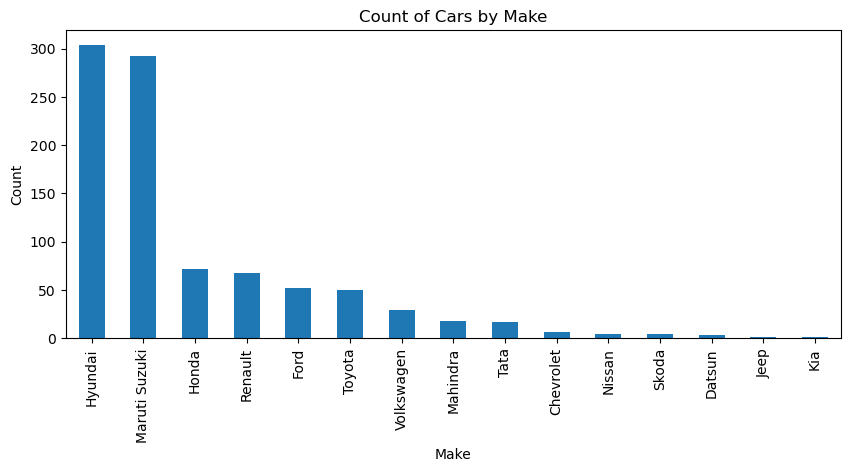

In [108]:
# Bar plot for categorical columns
df['Make'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title('Count of Cars by Make')
plt.ylabel('Count')
plt.show()

Make
Kia              1.369000e+06
Jeep             1.290000e+06
Mahindra         1.100167e+06
Nissan           8.842500e+05
Toyota           8.003400e+05
Honda            7.887222e+05
Tata             7.662941e+05
Ford             7.211731e+05
Hyundai          6.884375e+05
Skoda            6.847500e+05
Renault          6.625735e+05
Volkswagen       6.058276e+05
Maruti Suzuki    5.887850e+05
Chevrolet        4.535000e+05
Datsun           2.896667e+05
Name: Price, dtype: float64


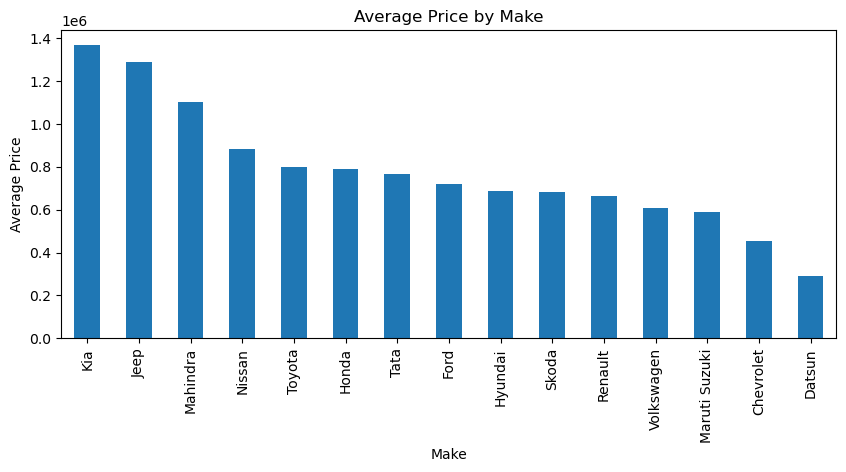

In [109]:
# Average price by make
avg_price_make = df.groupby('Make')['Price'].mean().sort_values(ascending=False)
print(avg_price_make)

avg_price_make.plot(kind='bar', figsize=(10,4))
plt.title('Average Price by Make')
plt.ylabel('Average Price')
plt.show()

Body_Type
suv          958993.506494
sedan        797080.000000
crossover    705095.238095
muv          626421.052632
hatchback    533977.272727
Name: Price, dtype: float64


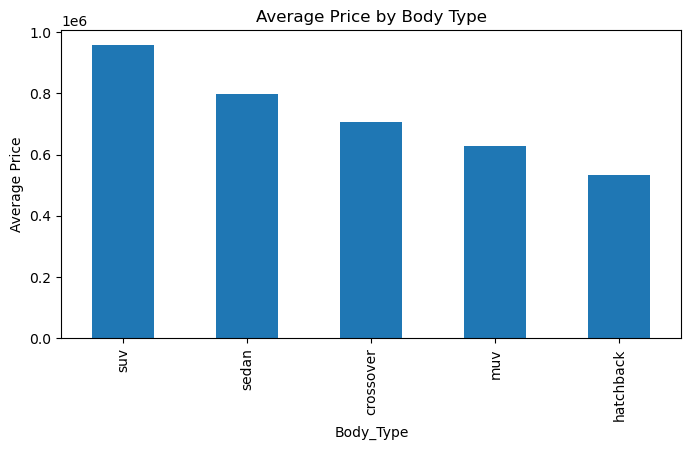

In [110]:
# Average price by body type
avg_price_body = df.groupby('Body_Type')['Price'].mean().sort_values(ascending=False)
print(avg_price_body)

avg_price_body.plot(kind='bar', figsize=(8,4))
plt.title('Average Price by Body Type')
plt.ylabel('Average Price')
plt.show()

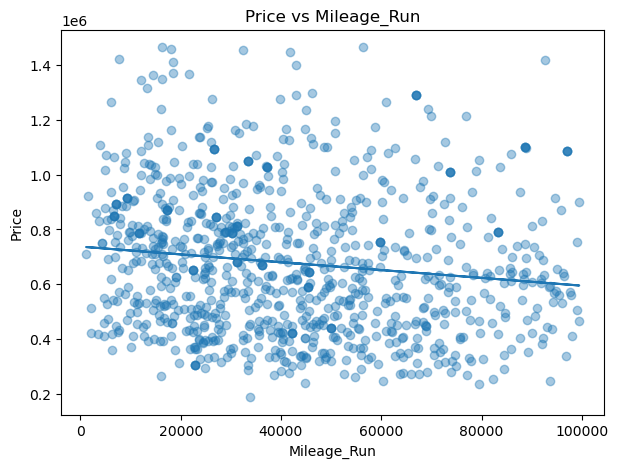

In [111]:
# Scatter plot of Price vs Mileage_Run with a regression line
plt.figure(figsize=(7,5))
plt.scatter(df['Mileage_Run'], df['Price'], alpha=0.4)

z = np.polyfit(df['Mileage_Run'], df['Price'], 1)
p = np.poly1d(z)
plt.plot(df['Mileage_Run'], p(df['Mileage_Run']))

plt.xlabel('Mileage_Run')
plt.ylabel('Price')
plt.title('Price vs Mileage_Run')
plt.show()

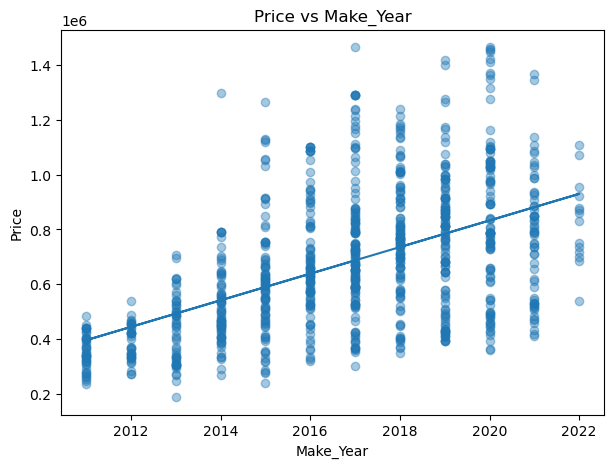

In [112]:
# Scatter plot of Price vs Make_Year with a regression line
plt.figure(figsize=(7,5))
plt.scatter(df['Make_Year'], df['Price'], alpha=0.4)

z = np.polyfit(df['Make_Year'], df['Price'], 1)
p = np.poly1d(z)
plt.plot(df['Make_Year'], p(df['Make_Year']))

plt.xlabel('Make_Year')
plt.ylabel('Price')
plt.title('Price vs Make_Year')
plt.show()

**1.1 Response:**

The EDA suggests that car prices are right-skewed and contain a small number of high-end observations, which supports using a log transformation for price. Mileage is also right-skewed, while make year is concentrated among more recent vehicles. Seating capacity has limited variation, with most cars having 5 seats. The categorical plots show strong imbalance across brands, with Hyundai and Maruti Suzuki making up much of the sample. Average prices vary substantially by both make and body type, with SUVs appearing most expensive on average and hatchbacks least expensive. However, brands with very small sample sizes should be interpreted cautiously. The scatter plot of price against mileage suggests a negative relationship, with higher-mileage cars generally selling for lower prices. The scatter plot of price against make year suggests a positive relationship, with newer cars tending to sell for higher prices. These patterns are consistent with economic intuition and support including both variables in the hedonic pricing model.

In [ ]:
# Part 2 : Categorical Variable Transformation ------------------------------------------------------------------------------------------------

# Choose target
y = df['Price']

# Separate the predictors
X = df.drop(columns=['Price'])

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type'], drop_first=True, dtype=int)

print(X.head())
print(X.shape)

   Make_Year  Mileage_Run  Seating_Capacity  log_price  log_mileage  \
0       2017        44611                 5  13.395439    10.705736   
1       2016        20305                 5  13.432785     9.918622   
2       2019        29540                 5  13.583579    10.293501   
3       2017        35680                 5  12.933621    10.482346   
4       2017        25126                 5  13.151922    10.131658   

   Make_Datsun  Make_Ford  Make_Honda  Make_Hyundai  Make_Jeep  ...  \
0            0          0           0             0          0  ...   
1            0          0           0             1          0  ...   
2            0          0           1             0          0  ...   
3            0          0           0             0          0  ...   
4            0          0           0             1          0  ...   

   Body_Type_suv  No_of_Owners_2nd  No_of_Owners_3rd  Fuel_Type_petrol  \
0              0                 0                 0                 0  

In [116]:
# Part 3 : 80/20 Train/Test Split ------------------------------------------------------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [ ]:
# Part 4

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Model 1: numeric variables only
X1_train = X_train[['Make_Year', 'Mileage_Run', 'Seating_Capacity']]
X1_test = X_test[['Make_Year', 'Mileage_Run', 'Seating_Capacity']]


# Model 2: all other columns (categorical/dummies only)
X2_train = X_train.drop(columns=['Make_Year', 'Mileage_Run', 'Seating_Capacity'])
X2_test = X_test.drop(columns=['Make_Year', 'Mileage_Run', 'Seating_Capacity'])


# Model 3: full model
X3_train = X_train
X3_test = X_test


# Fit the different models
reg1 = LinearRegression()
reg1.fit(X1_train, y_train)

reg2 = LinearRegression()
reg2.fit(X2_train, y_train)

reg3 = LinearRegression()
reg3.fit(X3_train, y_train)


# Predictions
pred1_train = reg1.predict(X1_train)
pred1_test = reg1.predict(X1_test)

pred2_train = reg2.predict(X2_train)
pred2_test = reg2.predict(X2_test)

pred3_train = reg3.predict(X3_train)
pred3_test = reg3.predict(X3_test)


# Results table
results = pd.DataFrame({
    'Model': ['Numeric only', 'Categorical only', 'Full model'],
    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, pred1_train)),
        np.sqrt(mean_squared_error(y_train, pred2_train)),
        np.sqrt(mean_squared_error(y_train, pred3_train))
    ],
    'Train R^2': [
        r2_score(y_train, pred1_train),
        r2_score(y_train, pred2_train),
        r2_score(y_train, pred3_train)
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, pred1_test)),
        np.sqrt(mean_squared_error(y_test, pred2_test)),
        np.sqrt(mean_squared_error(y_test, pred3_test))
    ],
    'Test R^2': [
        r2_score(y_test, pred1_test),
        r2_score(y_test, pred2_test),
        r2_score(y_test, pred3_test)
    ]
})

print(results)

              Model     Train RMSE  Train R^2      Test RMSE  Test R^2
0      Numeric only  203150.654685   0.357623  226328.204780  0.279601
1  Categorical only   46452.967429   0.966412   52434.346563  0.961334
2        Full model   46269.315405   0.966677   51729.217294  0.962367


**Response for Part 4:**

I fit three simple linear models: a numeric-only model, a categorical-only model, and a full model using all regressors. The numeric-only model performed the worst, with a test R2 of 0.2796 and a test RMSE of 226,328.20. The categorical-only model performed much better, with a test R2 of 0.9613 and a test RMSE of 52,434.35. The best model was the full model, which achieved a test R2 of 0.9624 and a test RMSE of 51,729.22. Thus, the full model performed best, although only slightly better than the categorical-only model, suggesting that most of the predictive power comes from the categorical features.

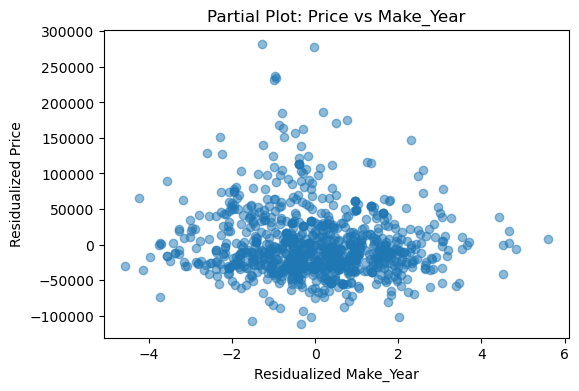

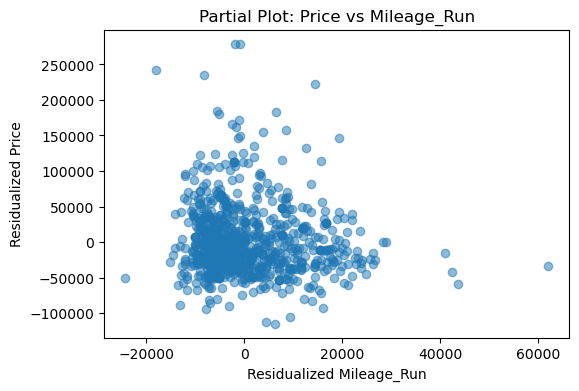

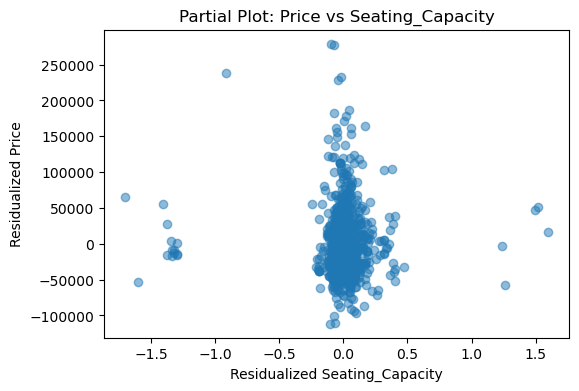

In [ ]:
# Part 5: Partial correlation plots ----------------------------------------------------------------------------------------------------------------------------

# Numeric variables only now
num_vars = ['Make_Year', 'Mileage_Run', 'Seating_Capacity']

for var in num_vars:

    # All regressors except the one we are plotting
    other_vars = X.drop(columns=[var])

    # Residuals of y after removing other regressors, essenitally cleaned "price" variable 
    reg_y = LinearRegression()
    reg_y.fit(other_vars, y)
    y_resid = y - reg_y.predict(other_vars) # Unexplained variance in price after controlling for other variables

    # Residuals of x_var after removing other regressors
    reg_x = LinearRegression()
    reg_x.fit(other_vars, X[var])
    x_resid = X[var] - reg_x.predict(other_vars) # Unexplained variance in x_var after controlling for other variables

    # Make the partial plots
    plt.figure(figsize=(6,4))
    plt.scatter(x_resid, y_resid, alpha=0.5)
    plt.xlabel("Residualized " + var)
    plt.ylabel("Residualized Price")
    plt.title("Partial Plot: Price vs " + var)
    plt.show()



**Part 5 Response:**

I created partial plots for the numeric variables using the full model, since it was the best-performing model and the categorical-only model contains no numeric regressors.

Overall, I do not see strong evidence of major nonlinearities in the numeric regressors. The partial plot for Make_Year appears fairly scattered without a clear curved pattern, and Seating_Capacity shows little structure, likely because it has limited variation in the sample. The strongest hint of nonlinearity appears in Mileage_Run, where the relationship with price does not look perfectly linear and may flatten or vary across the range. If I were to consider an additional transformation later, Mileage_Run would be the first candidate.

In [ ]:
# Part 6: Complex model with transformations and interactions ----------------------------------------------------------------------------------------------------------------------------

# Start from full model data
X_complex_train = X_train.copy()
X_complex_test = X_test.copy()

# Center numeric variables using training means
year_mean = X_train['Make_Year'].mean()
mile_mean = X_train['Mileage_Run'].mean()

X_complex_train['Make_Year_c'] = X_train['Make_Year'] - year_mean
X_complex_test['Make_Year_c'] = X_test['Make_Year'] - year_mean

X_complex_train['Mileage_Run_c'] = X_train['Mileage_Run'] - mile_mean
X_complex_test['Mileage_Run_c'] = X_test['Mileage_Run'] - mile_mean

# Transformations: Log and x^2
X_complex_train['log_Mileage_Run'] = np.log(X_train['Mileage_Run'])
X_complex_test['log_Mileage_Run'] = np.log(X_test['Mileage_Run'])

X_complex_train['Mileage_Run_c_sq'] = X_complex_train['Mileage_Run_c'] ** 2
X_complex_test['Mileage_Run_c_sq'] = X_complex_test['Mileage_Run_c'] ** 2

X_complex_train['Make_Year_c_sq'] = X_complex_train['Make_Year_c'] ** 2
X_complex_test['Make_Year_c_sq'] = X_complex_test['Make_Year_c'] ** 2

# Interaction terms
X_complex_train['Year_x_Mileage'] = X_complex_train['Make_Year_c'] * X_complex_train['Mileage_Run_c']
X_complex_test['Year_x_Mileage'] = X_complex_test['Make_Year_c'] * X_complex_test['Mileage_Run_c']

# Fit the complex model
reg_complex = LinearRegression()
reg_complex.fit(X_complex_train, y_train)

# Predictions
pred_complex_train = reg_complex.predict(X_complex_train)
pred_complex_test = reg_complex.predict(X_complex_test)

# Compute metrics for complex model
complex_train_rmse = np.sqrt(mean_squared_error(y_train, pred_complex_train))
complex_train_r2 = r2_score(y_train, pred_complex_train)

complex_test_rmse = np.sqrt(mean_squared_error(y_test, pred_complex_test))
complex_test_r2 = r2_score(y_test, pred_complex_test)

print("Complex model")
print("Train RMSE:", complex_train_rmse)
print("Train R^2:", complex_train_r2)
print("Test RMSE:", complex_test_rmse)
print("Test R^2:", complex_test_r2)

Complex model
Train RMSE: 43728.50372774735
Train R^2: 0.9702365774261987
Test RMSE: 49711.37281260632
Test R^2: 0.9652458257956504


**Part 6 Response:**

I built a more complex model by adding transformations and an interaction term to the full linear model. In particular, I included nonlinear features for the numeric variables and allowed mileage and year to interact. The complex model achieved a training RMSE of 43,728.50 and a training R2 of 0.9702, compared to 46,269.32 and 0.9667 for the simpler full model. On the test set, the complex model achieved an RMSE of 49,711.37 and an R2 of 0.9652, compared to 51,729.22 and 0.9624 for the simpler model. Thus, the more complex model performed slightly better out of sample, reducing test RMSE by about 2,018 and increasing test R2 by about 0.0029. This suggests that adding some nonlinear structure improved fit, although the gains were fairly modest.

**Part 7 Response:**

I began by cleaning the car-price dataset, removing the unused index column, checking variable types and missing values, and exploring the distributions of the variables. The EDA showed that Price and Mileage_Run were somewhat right-skewed, that most cars had a seating capacity of 5, and that prices varied substantially across makes and body types. In particular, categorical features such as Make, Body_Type, Fuel_Type, and Transmission_Type appeared to carry a great deal of information about price. I then transformed the categorical variables into dummy variables so they could be used in regression and split the data into an 80/20 training and test set. 

Among the simple linear models, the numeric-only model performed poorly, with test R2 of around 0.280, showing clear underfitting. The categorical-only model performed much better, with test R2 of around 0.961, and the full model using all variables performed best among the simple specifications, with test R2 of 0.962 and test RMSE of 51,729. This showed that most of the predictive power in this dataset comes from the categorical characteristics of the cars, while the numeric variables add only a small improvement on top of that. 

The partial plots for the numeric variables suggested that there was not strong evidence of major nonlinearities overall, although Mileage_Run showed the clearest hint that a transformation or nonlinear term might help. Based on that, I built a more complex model that added transformations and an interaction term. That model performed slightly better than the simple full model, achieving test R2 of 0.965 and test RMSE of 49,711.

Overall, this assignment taught me several things about model selection, underfitting, and overfitting. First, overly simple models can underfit badly, as shown by the numeric-only specification. Second, adding useful variables can dramatically improve predictive performance, as seen when categorical car characteristics were included. Third, adding complexity through transformations and interactions can help, but only when the added structure reflects real patterns in the data. In this case, the more complex model improved performance only slightly, which shows that more complexity does not automatically lead to large gains. Finally, model selection should be based on test-set performance rather than training-set fit alone, because the best model is the one that generalizes well to new data, not just the one that fits the training data most closely.